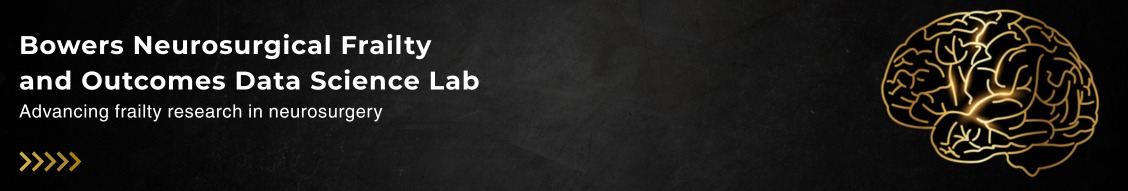

#### **This code was written by Omar M. M. Mansoor, feel free to reach out via email at omarmohmansoor@gmail.com**

### Packages

In [ ]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statannotations.Annotator import Annotator

### DataFrame

In [ ]:
df = pd.read_excel('', sheet_name='')

# All data cleaning and manipulation was done in excel

### Data Inspection

In [3]:
df.head(5)

,IMG/USMD,Name,Match year,Gender,PhD,TNRAP,1stPubs,2ndPubs,3rdPubs,4thPubs,5thorMorePubs,cPVU,cARCS,PVUgt1,PVUlt1,HEAI
0,IMG,Jose Sandoval Consuegra,2018,Male,No,0,0,0,0,0,0,0.0,0.0,0,0,0.0
1,USMD,Seung Won Jeong (Paul),2018,Male,No,0,0,0,0,0,0,0.0,0.0,0,0,0.0
2,USMD,Nathan Esplin,2018,Male,No,0,0,0,0,0,0,0.0,0.0,0,0,0.0
3,USMD,Shahed Elhamdani,2018,Male,No,0,0,0,0,0,0,0.0,0.0,0,0,0.0
4,IMG,Bhavika Gupta,2023,Female,No,0,0,0,0,0,0,0.0,0.0,0,0,0.0


## Statistical Analysis

### Shapiro-Wilk Normality

In [30]:
from scipy.stats import shapiro

In [31]:
def summary_stats(group):
    p_val = shapiro(group)[1]
    normality = "Normally Distributed" if p_val > 0.05 else "Skewed"
    return pd.Series({
        "Shapiro-Wilk Normality p Value": p_val,
        "Normality of the Data": normality
    })

table = df.select_dtypes(include='number').apply(summary_stats)

print(table)

table.to_excel("Shapiro-WilkTest.xlsx")

                               Match year   TNRAP 1stPubs 2ndPubs 3rdPubs  \
Shapiro-Wilk Normality p Value        0.0     0.0     0.0     0.0     0.0   
Normality of the Data              Skewed  Skewed  Skewed  Skewed  Skewed   

                               4thPubs 5thorMorePubs    cPVU   cARCS  PVUgt1  \
Shapiro-Wilk Normality p Value     0.0           0.0     0.0     0.0     0.0   
Normality of the Data           Skewed        Skewed  Skewed  Skewed  Skewed   

                                PVUlt1    HEAI  
Shapiro-Wilk Normality p Value     0.0     0.0  
Normality of the Data           Skewed  Skewed  


### Descriptive Statistics

In [32]:
def summary_stats(group):
    return pd.Series({
        "Median": group.median(),
        "IQR": group.quantile(0.75) - group.quantile(0.25),
        'Q75': group.quantile(0.75),
        'Q25': group.quantile(0.25),
        "Minimum": group.min(),
        "Maximum": group.max()
    })

table = df.select_dtypes(include='number').apply(summary_stats)

print(table)

table.to_excel("SummaryDescriptiveStatistics.xlsx")

         Match year  TNRAP  1stPubs  2ndPubs  3rdPubs  4thPubs  5thorMorePubs  \
Median       2021.0    7.0      2.0      1.0      1.0      0.0            1.0   
IQR             3.0   17.0      5.0      4.0      3.0      2.0            3.0   
Q75          2023.0   19.0      5.0      4.0      3.0      2.0            3.0   
Q25          2020.0    2.0      0.0      0.0      0.0      0.0            0.0   
Minimum      2018.0    0.0      0.0      0.0      0.0      0.0            0.0   
Maximum      2024.0  103.0     53.0     33.0     21.0     12.0           39.0   

             cPVU    cARCS  PVUgt1  PVUlt1     HEAI  
Median    10.7450    8.000     3.0     2.5   53.505  
IQR       28.2150   22.580     9.0     7.0   36.870  
Q75       31.7975   24.955    10.0     8.0   70.200  
Q25        3.5825    2.375     1.0     1.0   33.330  
Minimum    0.0000    0.000     0.0     0.0    0.000  
Maximum  213.9900  203.330    61.0    60.0  100.000  


### Mann-Whitney U

In [33]:
from scipy.stats import mannwhitneyu

#### IMG vs USMD

In [35]:
variables = ['TNRAP', 'cPVU', 'cARCS', 'PVUgt1', 'PVUlt1', 'HEAI']

results = []

for var in variables:
    img = df.loc[df['IMG/USMD'] == 'IMG', var]
    usmd = df.loc[df['IMG/USMD'] == 'USMD', var]
    u, p = mannwhitneyu(img, usmd, alternative='two-sided')
    results.append({
        "variable": var,
        "p_value": p})

results_df = pd.DataFrame(results)
    
def p_to_stars(p):
    if p < 0.0001:
        return "****"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

results_df['p_stars'] = results_df['p_value'].apply(p_to_stars)
print(results_df)

results_df.to_excel('MannWhitneyUGeneral.xlsx')

  variable   p_value p_stars
0    TNRAP  0.000004    ****
1     cPVU  0.000024    ****
2    cARCS  0.000028    ****
3   PVUgt1  0.000009    ****
4   PVUlt1  0.000014    ****
5     HEAI  0.906802      ns


##### Gender

In [36]:
results = []

variables = ['TNRAP', 'cPVU', 'cARCS', 'HEAI']

for g in df['IMG/USMD'].unique():
    group_data = df[df['IMG/USMD'] == g]
    
    for var in variables:
        hues = group_data['Gender'].unique()
        if len(hues) == 2:
            data1 = group_data[group_data['Gender'] == hues[0]][var]
            data2 = group_data[group_data['Gender'] == hues[1]][var]
            
            u, p = mannwhitneyu(data1, data2, alternative='two-sided')

            results.append({
                "group": g,
                "variable": var,
                "hue_comparison": f"{hues[0]} vs {hues[1]}",
                "p_value": p
            })

results_df = pd.DataFrame(results)

def p_to_stars(p):
    if p < 0.0001:
        return "****"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

results_df['p_star'] = results_df['p_value'].apply(p_to_stars)

print(results_df)
results_df.to_excel('MannWhitneyUGender.xlsx')


  group variable  hue_comparison   p_value p_star
0   IMG    TNRAP  Male vs Female  0.009066     **
1   IMG     cPVU  Male vs Female  0.002452     **
2   IMG    cARCS  Male vs Female  0.000983    ***
3   IMG     HEAI  Male vs Female  0.039050      *
4  USMD    TNRAP  Male vs Female  0.272026     ns
5  USMD     cPVU  Male vs Female  0.304851     ns
6  USMD    cARCS  Male vs Female  0.240558     ns
7  USMD     HEAI  Male vs Female  0.783822     ns


##### PhD

In [37]:
results = []

variables = ['TNRAP', 'cPVU', 'cARCS', 'HEAI']

for g in df['IMG/USMD'].unique():
    group_data = df[df['IMG/USMD'] == g]
    
    for var in variables:
        hues = group_data['PhD'].unique()
        if len(hues) == 2:
            data1 = group_data[group_data['PhD'] == hues[0]][var]
            data2 = group_data[group_data['PhD'] == hues[1]][var]
            
            u, p = mannwhitneyu(data1, data2, alternative='two-sided')

            results.append({
                "group": g,
                "variable": var,
                "hue_comparison": f"{hues[0]} vs {hues[1]}",
                "p_value": p
            })

results_df = pd.DataFrame(results)

def p_to_stars(p):
    if p < 0.0001:
        return "****"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

results_df['p_star'] = results_df['p_value'].apply(p_to_stars)

print(results_df)
results_df.to_excel('MannWhitneyUPhD.xlsx')

  group variable hue_comparison   p_value p_star
0   IMG    TNRAP      No vs Yes  0.396028     ns
1   IMG     cPVU      No vs Yes  0.518442     ns
2   IMG    cARCS      No vs Yes  0.517880     ns
3   IMG     HEAI      No vs Yes  0.086465     ns
4  USMD    TNRAP      No vs Yes  0.000343    ***
5  USMD     cPVU      No vs Yes  0.000032   ****
6  USMD    cARCS      No vs Yes  0.000017   ****
7  USMD     HEAI      No vs Yes  0.053396     ns


## Figures

### Fixed Plot Parameters

In [38]:
sns.set_context('paper')
sns.set_style('white')
mpl.rcParams['font.family'] = ['sans-serif']
mpl.rcParams['font.sans-serif'] = ['Arial']

### IMG vs USMD on Gender

In [39]:
custom_palette_gender={
    'Male':'gray',
    'Female':'#d5322c'
}

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

USMD_Male vs. USMD_Female: Mann-Whitney-Wilcoxon test two-sided, P_val:2.720e-01 U_stat=2.143e+03
IMG_Male vs. IMG_Female: Mann-Whitney-Wilcoxon test two-sided, P_val:9.066e-03 U_stat=1.722e+03
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

IMG vs. USMD: Mann-Whitney-Wilcoxon test two-sided, P_val:4.219e-06 U_stat=1.219e+04


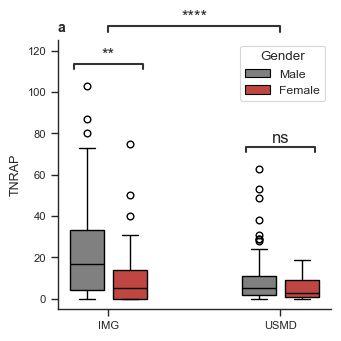

In [40]:
fig = plt.figure(figsize=(3.5,3.5))

ax = sns.boxplot(df, x='IMG/USMD', y='TNRAP', hue='Gender', legend=True, width=0.5, fill=True, palette=custom_palette_gender, gap=0.22, linecolor='black')
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='x', bottom=True, direction='out', labelsize=8)
ax.tick_params(axis='y', left=True, direction='out', labelsize=8)
ax.set_xlabel('')
ax.set_ylabel('TNRAP', fontsize=9)
ax.set_title('a', fontsize=10, weight='bold', loc='left')

pairs = [
    (("IMG", "Male"), ("IMG", "Female")),
    (("USMD", "Male"), ("USMD", "Female"))
]
pair_nohue = [('IMG', 'USMD')]

annotator = Annotator(ax, pairs, data=df, x='IMG/USMD', y='TNRAP', hue='Gender')
annotator.configure(test='Mann-Whitney', text_format='star', loc='inside', fontsize=12)
annotator.apply_and_annotate()

annotator = Annotator(ax, pair_nohue, data=df, x='IMG/USMD', y='TNRAP')
annotator.configure(test='Mann-Whitney', text_format='star', loc='outside', fontsize=12, line_offset=0.5, line_offset_to_group=0.05)
annotator.apply_and_annotate()

plt.tight_layout()
plt.savefig('figure1a.svg', dpi=800, bbox_inches='tight')

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

USMD_Male vs. USMD_Female: Mann-Whitney-Wilcoxon test two-sided, P_val:3.049e-01 U_stat=2.128e+03
IMG_Male vs. IMG_Female: Mann-Whitney-Wilcoxon test two-sided, P_val:2.452e-03 U_stat=1.792e+03
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

IMG vs. USMD: Mann-Whitney-Wilcoxon test two-sided, P_val:2.376e-05 U_stat=1.195e+04


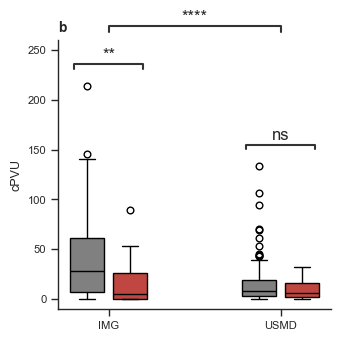

In [41]:
fig = plt.figure(figsize=(3.5,3.5))

ax = sns.boxplot(df, x='IMG/USMD', y='cPVU', hue='Gender', legend=False, width=0.5, fill=True, palette=custom_palette_gender, gap=0.22, linecolor='black')
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='x', bottom=True, direction='out', labelsize=8)
ax.tick_params(axis='y', left=True, direction='out', labelsize=8)
ax.set_xlabel('')
ax.set_ylabel('cPVU', fontsize=9)
ax.set_title('b', fontsize=10, weight='bold', loc='left')

pairs = [
    (("IMG", "Male"), ("IMG", "Female")),
    (("USMD", "Male"), ("USMD", "Female"))
]
pair_nohue = [('IMG', 'USMD')]

annotator = Annotator(ax, pairs, data=df, x='IMG/USMD', y='cPVU', hue='Gender')
annotator.configure(test='Mann-Whitney', text_format='star', loc='inside', fontsize=12)
annotator.apply_and_annotate()

annotator = Annotator(ax, pair_nohue, data=df, x='IMG/USMD', y='cPVU')
annotator.configure(test='Mann-Whitney', text_format='star', loc='outside', fontsize=12, line_offset=0.5, line_offset_to_group=0.05)
annotator.apply_and_annotate()


plt.tight_layout()
plt.savefig('figure1b.svg', dpi=800, bbox_inches='tight')

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

USMD_Male vs. USMD_Female: Mann-Whitney-Wilcoxon test two-sided, P_val:2.406e-01 U_stat=2.159e+03
IMG_Male vs. IMG_Female: Mann-Whitney-Wilcoxon test two-sided, P_val:9.829e-04 U_stat=1.835e+03
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

IMG vs. USMD: Mann-Whitney-Wilcoxon test two-sided, P_val:2.760e-05 U_stat=1.192e+04


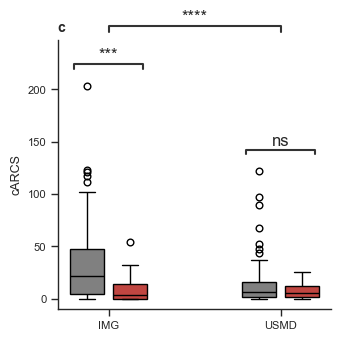

In [42]:
fig = plt.figure(figsize=(3.5,3.5))

ax = sns.boxplot(df, x='IMG/USMD', y='cARCS', hue='Gender', legend=False, width=0.5, fill=True, palette=custom_palette_gender, gap=0.22, linecolor='black')
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='x', bottom=True, direction='out', labelsize=8)
ax.tick_params(axis='y', left=True, direction='out', labelsize=8)
ax.set_xlabel('')
ax.set_ylabel('cARCS', fontsize=9)
ax.set_title('c', fontsize=10, weight='bold', loc='left')

pairs = [
    (("IMG", "Male"), ("IMG", "Female")),
    (("USMD", "Male"), ("USMD", "Female"))
]
pair_nohue = [('IMG', 'USMD')]

annotator = Annotator(ax, pairs, data=df, x='IMG/USMD', y='cARCS', hue='Gender')
annotator.configure(test='Mann-Whitney', text_format='star', loc='inside', fontsize=12)
annotator.apply_and_annotate()

annotator = Annotator(ax, pair_nohue, data=df, x='IMG/USMD', y='cARCS')
annotator.configure(test='Mann-Whitney', text_format='star', loc='outside', fontsize=12, line_offset=0.5, line_offset_to_group=0.05)
annotator.apply_and_annotate()


plt.tight_layout()
plt.savefig('figure1c.svg', dpi=800, bbox_inches='tight')

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

USMD_Male vs. USMD_Female: Mann-Whitney-Wilcoxon test two-sided, P_val:4.394e-01 U_stat=2.072e+03
IMG_Male vs. IMG_Female: Mann-Whitney-Wilcoxon test two-sided, P_val:1.382e-03 U_stat=1.818e+03
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

IMG vs. USMD: Mann-Whitney-Wilcoxon test two-sided, P_val:9.417e-06 U_stat=1.207e+04


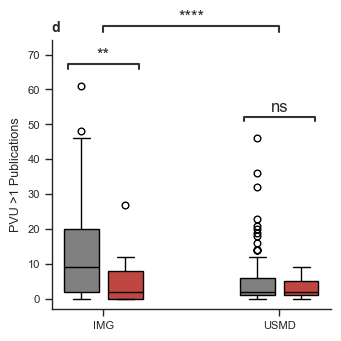

In [43]:
fig = plt.figure(figsize=(3.5,3.5))

ax = sns.boxplot(df, x='IMG/USMD', y='PVUgt1', hue='Gender', legend=False, width=0.5, fill=True, palette=custom_palette_gender, gap=0.22, linecolor='black')
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='x', bottom=True, direction='out', labelsize=8)
ax.tick_params(axis='y', left=True, direction='out', labelsize=8)
ax.set_xlabel('')
ax.set_ylabel('PVU >1 Publications', fontsize=9)
ax.set_title('d', fontsize=10, weight='bold', loc='left')

pairs = [
    (("IMG", "Male"), ("IMG", "Female")),
    (("USMD", "Male"), ("USMD", "Female"))
]
pair_nohue = [('IMG', 'USMD')]

annotator = Annotator(ax, pairs, data=df, x='IMG/USMD', y='PVUgt1', hue='Gender')
annotator.configure(test='Mann-Whitney', text_format='star', loc='inside', fontsize=12)
annotator.apply_and_annotate()

annotator = Annotator(ax, pair_nohue, data=df, x='IMG/USMD', y='PVUgt1')
annotator.configure(test='Mann-Whitney', text_format='star', loc='outside', fontsize=12, line_offset=0.5, line_offset_to_group=0.05)
annotator.apply_and_annotate()


plt.tight_layout()
plt.savefig('figure1d.svg', dpi=800, bbox_inches='tight')

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

USMD_Male vs. USMD_Female: Mann-Whitney-Wilcoxon test two-sided, P_val:3.853e-01 U_stat=2.091e+03
IMG_Male vs. IMG_Female: Mann-Whitney-Wilcoxon test two-sided, P_val:9.448e-03 U_stat=1.718e+03
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

IMG vs. USMD: Mann-Whitney-Wilcoxon test two-sided, P_val:1.449e-05 U_stat=1.200e+04


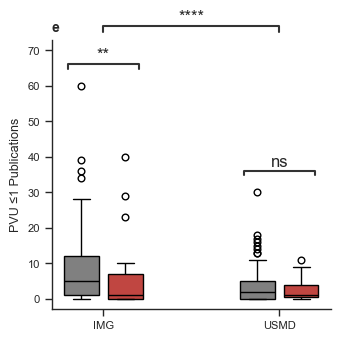

In [77]:
fig = plt.figure(figsize=(3.5,3.5))

ax = sns.boxplot(df, x='IMG/USMD', y='PVUlt1', hue='Gender', legend=False, width=0.5, fill=True, palette=custom_palette_gender, gap=0.22, linecolor='black')
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='x', bottom=True, direction='out', labelsize=8)
ax.tick_params(axis='y', left=True, direction='out', labelsize=8)
ax.set_xlabel('')
ax.set_ylabel('PVU ≤1 Publications', fontsize=9)
ax.set_title('e', fontsize=10, weight='bold', loc='left')

pairs = [
    (("IMG", "Male"), ("IMG", "Female")),
    (("USMD", "Male"), ("USMD", "Female"))
]
pair_nohue = [('IMG', 'USMD')]

annotator = Annotator(ax, pairs, data=df, x='IMG/USMD', y='PVUlt1', hue='Gender')
annotator.configure(test='Mann-Whitney', text_format='star', loc='inside', fontsize=12)
annotator.apply_and_annotate()

annotator = Annotator(ax, pair_nohue, data=df, x='IMG/USMD', y='PVUlt1')
annotator.configure(test='Mann-Whitney', text_format='star', loc='outside', fontsize=12, line_offset=0.5, line_offset_to_group=0.05)
annotator.apply_and_annotate()


plt.tight_layout()
plt.savefig('figure1e.svg', dpi=800, bbox_inches='tight')

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

USMD_Male vs. USMD_Female: Mann-Whitney-Wilcoxon test two-sided, P_val:7.838e-01 U_stat=1.848e+03
IMG_Male vs. IMG_Female: Mann-Whitney-Wilcoxon test two-sided, P_val:3.905e-02 U_stat=1.630e+03
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

IMG vs. USMD: Mann-Whitney-Wilcoxon test two-sided, P_val:9.068e-01 U_stat=9.140e+03


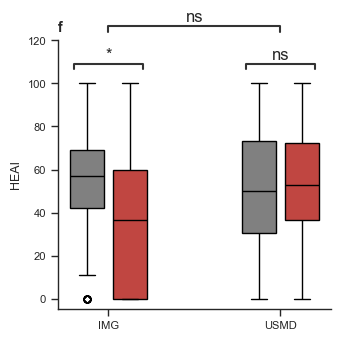

In [45]:
fig = plt.figure(figsize=(3.5,3.5))

ax = sns.boxplot(df, x='IMG/USMD', y='HEAI', hue='Gender', legend=False, width=0.5, fill=True, palette=custom_palette_gender, gap=0.22, linecolor='black')
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='x', bottom=True, direction='out', labelsize=8)
ax.tick_params(axis='y', left=True, direction='out', labelsize=8)
ax.set_xlabel('')
ax.set_ylabel('HEAI', fontsize=9)
ax.set_title('f', fontsize=10, weight='bold', loc='left')

pairs = [
    (("IMG", "Male"), ("IMG", "Female")),
    (("USMD", "Male"), ("USMD", "Female"))
]
pair_nohue = [('IMG', 'USMD')]

annotator = Annotator(ax, pairs, data=df, x='IMG/USMD', y='HEAI', hue='Gender')
annotator.configure(test='Mann-Whitney', text_format='star', loc='inside', fontsize=12)
annotator.apply_and_annotate()

annotator = Annotator(ax, pair_nohue, data=df, x='IMG/USMD', y='HEAI')
annotator.configure(test='Mann-Whitney', text_format='star', loc='outside', fontsize=12, line_offset=0.5, line_offset_to_group=0.05)
annotator.apply_and_annotate()


plt.tight_layout()
plt.savefig('figure1f.svg', dpi=800, bbox_inches='tight')

In [176]:
## Note: The boxplots below will not have significant bars comparing between IMGs and USMDs as whole. The boxplots for Gender already did that. I # the code incase we want to keep them, but I see no need for them as we've already demonstrated them above

### IMG vs USMD on PhD

In [5]:
custom_palette_phd={
    'Yes':'gray',
    'No':'#d5322c'
}

In [6]:
sns.set_context('paper')
sns.set_style('white')
mpl.rcParams['font.family'] = ['sans-serif']
mpl.rcParams['font.sans-serif'] = ['Arial']

# I passed those parameters again just incase

In [4]:
order = ['Yes', 'No']

df['PhD'] = pd.Categorical(df['PhD'], categories=order, ordered=True)

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

USMD_Yes vs. USMD_No: Mann-Whitney-Wilcoxon test two-sided, P_val:3.431e-04 U_stat=1.985e+03
IMG_Yes vs. IMG_No: Mann-Whitney-Wilcoxon test two-sided, P_val:3.960e-01 U_stat=9.095e+02


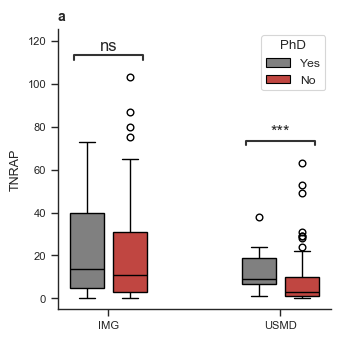

In [7]:
fig = plt.figure(figsize=(3.5,3.5))

ax = sns.boxplot(df, x='IMG/USMD', y='TNRAP', hue='PhD', legend=True, width=0.5, fill=True, palette=custom_palette_phd, gap=0.22, linecolor='black')
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='x', bottom=True, direction='out', labelsize=8)
ax.tick_params(axis='y', left=True, direction='out', labelsize=8)
ax.set_xlabel('')
ax.set_ylabel('TNRAP', fontsize=9)
ax.set_title('a', fontsize=10, weight='bold', loc='left')

pairs = [
    (("IMG", "Yes"), ("IMG", "No")),
    (("USMD", "Yes"), ("USMD", "No"))
]
#pair_nohue = [('IMG', 'USMD')]

annotator = Annotator(ax, pairs, data=df, x='IMG/USMD', y='TNRAP', hue='PhD')
annotator.configure(test='Mann-Whitney', text_format='star', loc='inside', fontsize=12)
annotator.apply_and_annotate()

#annotator = Annotator(ax, pair_nohue, data=df, x='IMG/USMD', y='TNRAP')
#annotator.configure(test='Mann-Whitney', text_format='star', loc='outside', fontsize=12, line_offset=0.5, line_offset_to_group=0.05)
#annotator.apply_and_annotate()


plt.tight_layout()
plt.savefig('figure2a.svg', dpi=800, bbox_inches='tight')

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

USMD_Yes vs. USMD_No: Mann-Whitney-Wilcoxon test two-sided, P_val:3.192e-05 U_stat=2.090e+03
IMG_Yes vs. IMG_No: Mann-Whitney-Wilcoxon test two-sided, P_val:5.184e-01 U_stat=8.830e+02


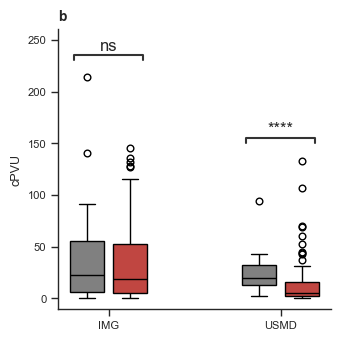

In [8]:
fig = plt.figure(figsize=(3.5,3.5))

ax = sns.boxplot(df, x='IMG/USMD', y='cPVU', hue='PhD', legend=False, width=0.5, fill=True, palette=custom_palette_phd, gap=0.22, linecolor='black')
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='x', bottom=True, direction='out', labelsize=8)
ax.tick_params(axis='y', left=True, direction='out', labelsize=8)
ax.set_xlabel('')
ax.set_ylabel('cPVU', fontsize=9)
ax.set_title('b', fontsize=10, weight='bold', loc='left')

pairs = [
    (("IMG", "Yes"), ("IMG", "No")),
    (("USMD", "Yes"), ("USMD", "No"))
]
#pair_nohue = [('IMG', 'USMD')]

annotator = Annotator(ax, pairs, data=df, x='IMG/USMD', y='cPVU', hue='PhD')
annotator.configure(test='Mann-Whitney', text_format='star', loc='inside', fontsize=12)
annotator.apply_and_annotate()

#annotator = Annotator(ax, pair_nohue, data=df, x='IMG/USMD', y='cPVU')
#annotator.configure(test='Mann-Whitney', text_format='star', loc='outside', fontsize=12, line_offset=0.5, line_offset_to_group=0.05)
#annotator.apply_and_annotate()


plt.tight_layout()
plt.savefig('figure2b.svg', dpi=800, bbox_inches='tight')

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

USMD_Yes vs. USMD_No: Mann-Whitney-Wilcoxon test two-sided, P_val:1.724e-05 U_stat=2.114e+03
IMG_Yes vs. IMG_No: Mann-Whitney-Wilcoxon test two-sided, P_val:5.179e-01 U_stat=8.830e+02


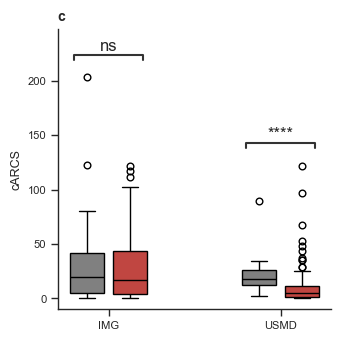

In [9]:
fig = plt.figure(figsize=(3.5,3.5))

ax = sns.boxplot(df, x='IMG/USMD', y='cARCS', hue='PhD', legend=False, width=0.5, fill=True, palette=custom_palette_phd, gap=0.22, linecolor='black')
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='x', bottom=True, direction='out', labelsize=8)
ax.tick_params(axis='y', left=True, direction='out', labelsize=8)
ax.set_xlabel('')
ax.set_ylabel('cARCS', fontsize=9)
ax.set_title('c', fontsize=10, weight='bold', loc='left')

pairs = [
    (("IMG", "Yes"), ("IMG", "No")),
    (("USMD", "Yes"), ("USMD", "No"))
]
#pair_nohue = [('IMG', 'USMD')]

annotator = Annotator(ax, pairs, data=df, x='IMG/USMD', y='cARCS', hue='PhD')
annotator.configure(test='Mann-Whitney', text_format='star', loc='inside', fontsize=12)
annotator.apply_and_annotate()

#annotator = Annotator(ax, pair_nohue, data=df, x='IMG/USMD', y='cARCS')
#annotator.configure(test='Mann-Whitney', text_format='star', loc='outside', fontsize=12, line_offset=0.5, line_offset_to_group=0.05)
#annotator.apply_and_annotate()


plt.tight_layout()
plt.savefig('figure2c.svg', dpi=800, bbox_inches='tight')

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

USMD_Yes vs. USMD_No: Mann-Whitney-Wilcoxon test two-sided, P_val:5.474e-05 U_stat=2.062e+03
IMG_Yes vs. IMG_No: Mann-Whitney-Wilcoxon test two-sided, P_val:4.646e-01 U_stat=8.940e+02


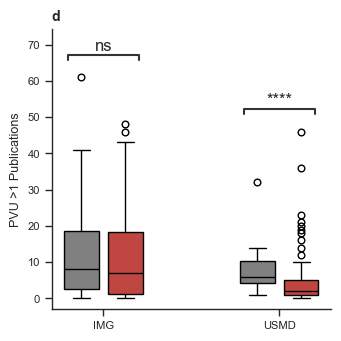

In [10]:
fig = plt.figure(figsize=(3.5,3.5))

ax = sns.boxplot(df, x='IMG/USMD', y='PVUgt1', hue='PhD', legend=False, width=0.5, fill=True, palette=custom_palette_phd, gap=0.22, linecolor='black')
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='x', bottom=True, direction='out', labelsize=8)
ax.tick_params(axis='y', left=True, direction='out', labelsize=8)
ax.set_xlabel('')
ax.set_ylabel('PVU >1 Publications', fontsize=9)
ax.set_title('d', fontsize=10, weight='bold', loc='left')

pairs = [
    (("IMG", "Yes"), ("IMG", "No")),
    (("USMD", "Yes"), ("USMD", "No"))
]
#pair_nohue = [('IMG', 'USMD')]

annotator = Annotator(ax, pairs, data=df, x='IMG/USMD', y='PVUgt1', hue='PhD')
annotator.configure(test='Mann-Whitney', text_format='star', loc='inside', fontsize=12)
annotator.apply_and_annotate()

#annotator = Annotator(ax, pair_nohue, data=df, x='IMG/USMD', y='PVUgt1')
#annotator.configure(test='Mann-Whitney', text_format='star', loc='outside', fontsize=12, line_offset=0.5, line_offset_to_group=0.05)
#annotator.apply_and_annotate()


plt.tight_layout()
plt.savefig('figure2d.svg', dpi=800, bbox_inches='tight')

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

USMD_Yes vs. USMD_No: Mann-Whitney-Wilcoxon test two-sided, P_val:6.351e-03 U_stat=1.825e+03
IMG_Yes vs. IMG_No: Mann-Whitney-Wilcoxon test two-sided, P_val:7.588e-01 U_stat=8.385e+02


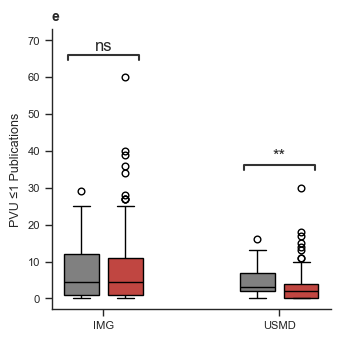

In [11]:
fig = plt.figure(figsize=(3.5,3.5))

ax = sns.boxplot(df, x='IMG/USMD', y='PVUlt1', hue='PhD', legend=False, width=0.5, fill=True, palette=custom_palette_phd, gap=0.22, linecolor='black')
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='x', bottom=True, direction='out', labelsize=8)
ax.tick_params(axis='y', left=True, direction='out', labelsize=8)
ax.set_xlabel('')
ax.set_ylabel('PVU ≤1 Publications', fontsize=9)
ax.set_title('e', fontsize=10, weight='bold', loc='left')

pairs = [
    (("IMG", "Yes"), ("IMG", "No")),
    (("USMD", "Yes"), ("USMD", "No"))
]
#pair_nohue = [('IMG', 'USMD')]

annotator = Annotator(ax, pairs, data=df, x='IMG/USMD', y='PVUlt1', hue='PhD')
annotator.configure(test='Mann-Whitney', text_format='star', loc='inside', fontsize=12)
annotator.apply_and_annotate()

#annotator = Annotator(ax, pair_nohue, data=df, x='IMG/USMD', y='PVUlt1')
#annotator.configure(test='Mann-Whitney', text_format='star', loc='outside', fontsize=12, line_offset=0.5, line_offset_to_group=0.05)
#annotator.apply_and_annotate()


plt.tight_layout()
plt.savefig('figure2e.svg', dpi=800, bbox_inches='tight')

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

USMD_Yes vs. USMD_No: Mann-Whitney-Wilcoxon test two-sided, P_val:5.340e-02 U_stat=1.688e+03
IMG_Yes vs. IMG_No: Mann-Whitney-Wilcoxon test two-sided, P_val:8.647e-02 U_stat=1.022e+03


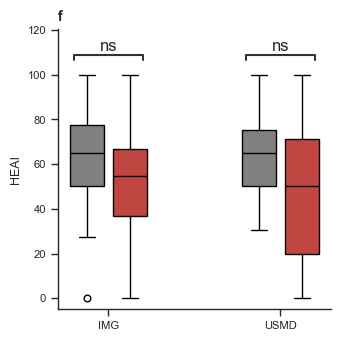

In [12]:
fig = plt.figure(figsize=(3.5,3.5))

ax = sns.boxplot(df, x='IMG/USMD', y='HEAI', hue='PhD', legend=False, width=0.5, fill=True, palette=custom_palette_phd, gap=0.22, linecolor='black')
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='x', bottom=True, direction='out', labelsize=8)
ax.tick_params(axis='y', left=True, direction='out', labelsize=8)
ax.set_xlabel('')
ax.set_ylabel('HEAI', fontsize=9)
ax.set_title('f', fontsize=10, weight='bold', loc='left')

pairs = [
    (("IMG", "Yes"), ("IMG", "No")),
    (("USMD", "Yes"), ("USMD", "No"))
]
#pair_nohue = [('IMG', 'USMD')]

annotator = Annotator(ax, pairs, data=df, x='IMG/USMD', y='HEAI', hue='PhD')
annotator.configure(test='Mann-Whitney', text_format='star', loc='inside', fontsize=12)
annotator.apply_and_annotate()

#annotator = Annotator(ax, pair_nohue, data=df, x='IMG/USMD', y='HEAI')
#annotator.configure(test='Mann-Whitney', text_format='star', loc='outside', fontsize=12, line_offset=0.5, line_offset_to_group=0.05)
#annotator.apply_and_annotate()

plt.tight_layout()
plt.savefig('figure2f.svg', dpi=800, bbox_inches='tight')

### KDE Plots

In [126]:
custom_palette_kde={
    'USMD':'gray',
    'IMG':'#d5322c'
}

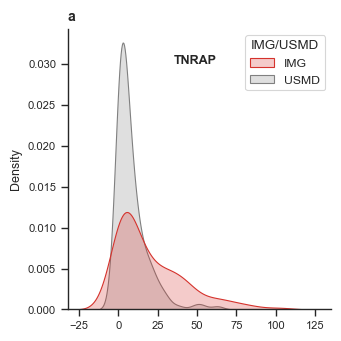

In [127]:
fig = plt.figure(figsize=(3.5,3.5))

ax = sns.kdeplot(df, x='TNRAP', hue='IMG/USMD', palette=custom_palette_kde, fill=True)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='x', bottom=True, direction='out', labelsize=8)
ax.tick_params(axis='y', left=True, direction='out', labelsize=8)
ax.set_xlabel('')
ax.set_ylabel('Density', fontsize=9)
ax.set_title('a', fontsize=10, weight='bold', loc='left')
ax.text(x=35, y=0.03, s='TNRAP', fontsize=9, weight='bold')

plt.tight_layout()
plt.savefig('figure3a.svg', dpi=800, bbox_inches='tight')

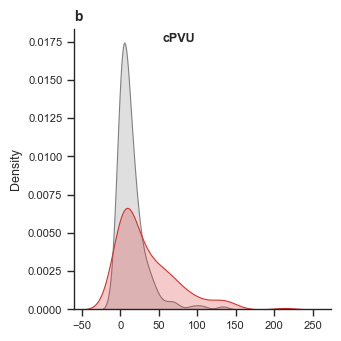

In [56]:
fig = plt.figure(figsize=(3.5,3.5))

ax = sns.kdeplot(df, x='cPVU', hue='IMG/USMD', palette=custom_palette_kde, fill=True, legend=False)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='x', bottom=True, direction='out', labelsize=8)
ax.tick_params(axis='y', left=True, direction='out', labelsize=8)
ax.set_xlabel('')
ax.set_ylabel('Density', fontsize=9)
ax.set_title('b', fontsize=10, weight='bold', loc='left')
ax.text(x=55, y=0.0175, s='cPVU', fontsize=9, weight='bold')

plt.tight_layout()
plt.savefig('figure3b.svg', dpi=800, bbox_inches='tight')

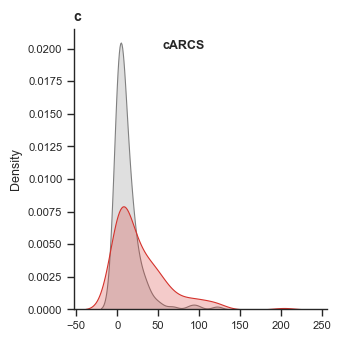

In [57]:
fig = plt.figure(figsize=(3.5,3.5))

ax = sns.kdeplot(df, x='cARCS', hue='IMG/USMD', palette=custom_palette_kde, fill=True, legend=False)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='x', bottom=True, direction='out', labelsize=8)
ax.tick_params(axis='y', left=True, direction='out', labelsize=8)
ax.set_xlabel('')
ax.set_ylabel('Density', fontsize=9)
ax.set_title('c', fontsize=10, weight='bold', loc='left')
ax.text(x=55, y=0.02, s='cARCS', fontsize=9, weight='bold')

plt.tight_layout()
plt.savefig('figure3c.svg', dpi=800, bbox_inches='tight')

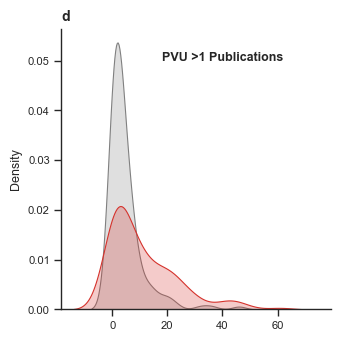

In [58]:
fig = plt.figure(figsize=(3.5,3.5))

ax = sns.kdeplot(df, x='PVUgt1', hue='IMG/USMD', palette=custom_palette_kde, fill=True, legend=False)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='x', bottom=True, direction='out', labelsize=8)
ax.tick_params(axis='y', left=True, direction='out', labelsize=8)
ax.set_xlabel('')
ax.set_ylabel('Density', fontsize=9)
ax.set_title('d', fontsize=10, weight='bold', loc='left')
ax.text(x=18, y=0.05, s='PVU >1 Publications', fontsize=9, weight='bold')

plt.tight_layout()
plt.savefig('figure3d.svg', dpi=800, bbox_inches='tight')

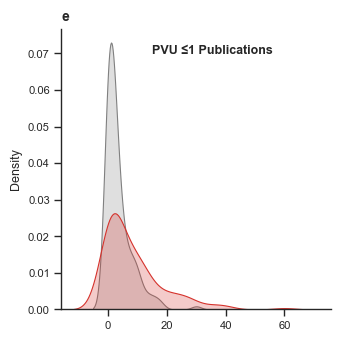

In [75]:
fig = plt.figure(figsize=(3.5,3.5))

ax = sns.kdeplot(df, x='PVUlt1', hue='IMG/USMD', palette=custom_palette_kde, fill=True, legend=False)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='x', bottom=True, direction='out', labelsize=8)
ax.tick_params(axis='y', left=True, direction='out', labelsize=8)
ax.set_xlabel('')
ax.set_ylabel('Density', fontsize=9)
ax.set_title('e', fontsize=10, weight='bold', loc='left')
ax.text(x=15, y=0.07, s='PVU ≤1 Publications', fontsize=9, weight='bold')

plt.tight_layout()
plt.savefig('figure3e.svg', dpi=800, bbox_inches='tight')

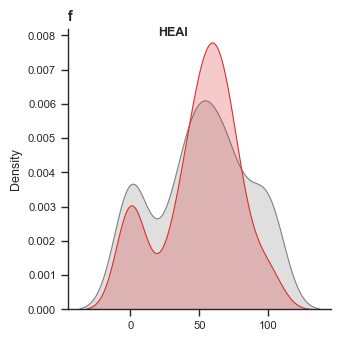

In [60]:
fig = plt.figure(figsize=(3.5,3.5))

ax = sns.kdeplot(df, x='HEAI', hue='IMG/USMD', palette=custom_palette_kde, fill=True, legend=False)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='x', bottom=True, direction='out', labelsize=8)
ax.tick_params(axis='y', left=True, direction='out', labelsize=8)
ax.set_xlabel('')
ax.set_ylabel('Density', fontsize=9)
ax.set_title('f', fontsize=10, weight='bold', loc='left')
ax.text(x=20, y=0.008, s='HEAI', fontsize=9, weight='bold')

plt.tight_layout()
plt.savefig('figure3f.svg', dpi=800, bbox_inches='tight')

### Bar-Charts for Authorship Division

In [3]:
sns.set_context('paper')
sns.set_style('white')
mpl.rcParams['font.family'] = ['sans-serif']
mpl.rcParams['font.sans-serif'] = ['Arial']

In [4]:
custom_palette_bar={
    'USMD':'gray',
    'IMG':'#d5322c'
}

In [13]:
df_img = df[df['IMG/USMD'] == 'IMG']
df_usmd = df[df['IMG/USMD'] == 'USMD']

In [5]:
import starbars

In [48]:
df.groupby(['IMG/USMD'])['1stPubs'].sum()

IMG/USMD
IMG     797
USMD    340
Name: 1stPubs, dtype: int64

In [ ]:
df.groupby(['IMG/USMD'])['2ndPubs'].sum()

IMG/USMD
IMG     576
USMD    279
Name: 2ndPubs, dtype: int64

In [ ]:
df.groupby(['IMG/USMD'])['3rdPubs'].sum()

IMG/USMD
IMG     410
USMD    187
Name: 3rdPubs, dtype: int64

In [ ]:
df.groupby(['IMG/USMD'])['4thPubs'].sum()

IMG/USMD
IMG     234
USMD    128
Name: 4thPubs, dtype: int64

In [ ]:
df.groupby(['IMG/USMD'])['5thorMorePubs'].sum()

IMG/USMD
IMG     538
USMD    243
Name: 5thorMorePubs, dtype: int64

Percentage Difference Values

1st pubs = 80.387% difference

2nd pubs = 69.4737% difference 

3rd pubs = 74.7069% difference

4th pubs = 58.5635% difference

5th or more pubs = 75.5442% difference

C:\Users\JC\AppData\Local\Temp\ipykernel_24156\293088273.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(df, x='IMG/USMD', y='1stPubs', errorbar=None, estimator=np.sum, fill=True, palette=custom_palette_bar, edgecolor='black', gap=0.25, saturation=0.55)


2.0 0.03


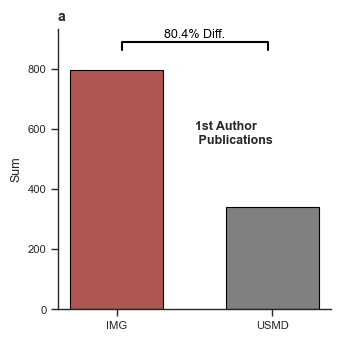

In [77]:
fig = plt.figure(figsize=(3.5,3.5))

ax = sns.barplot(df, x='IMG/USMD', y='1stPubs', errorbar=None, estimator=np.sum, fill=True, palette=custom_palette_bar, edgecolor='black', gap=0.25, saturation=0.55)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='x', bottom=True, direction='out', labelsize=8)
ax.tick_params(axis='y', left=True, direction='out', labelsize=8)
ax.set_xlabel('')
ax.set_ylabel('Sum', fontsize=9)
ax.set_title('a', fontsize=10, weight='bold', loc='left')
ax.text(x=0.5, y=550, s='1st Author \n Publications', fontsize=9, weight='bold')
annotations = [('IMG', 'USMD', '80.4% Diff.')]
starbars.draw_annotation(annotations, text_distance=0.03, fontsize=9)

plt.tight_layout()
plt.savefig('figure4a.svg', dpi=800, bbox_inches='tight')

C:\Users\JC\AppData\Local\Temp\ipykernel_24156\785290255.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(df, x='IMG/USMD', y='2ndPubs', estimator=np.sum, errorbar=None, fill=True, palette=custom_palette_bar, edgecolor='black', gap=0.25, saturation=0.55)


2.0 0.03


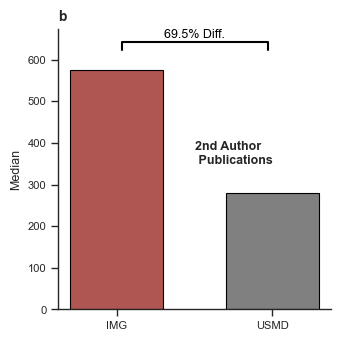

In [78]:
fig = plt.figure(figsize=(3.5,3.5))

ax = sns.barplot(df, x='IMG/USMD', y='2ndPubs', estimator=np.sum, errorbar=None, fill=True, palette=custom_palette_bar, edgecolor='black', gap=0.25, saturation=0.55)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='x', bottom=True, direction='out', labelsize=8)
ax.tick_params(axis='y', left=True, direction='out', labelsize=8)
ax.set_xlabel('')
ax.set_ylabel('Median', fontsize=9)
ax.set_title('b', fontsize=10, weight='bold', loc='left')
ax.text(x=0.5, y=350, s='2nd Author \n Publications', fontsize=9, weight='bold')
annotations = [('IMG', 'USMD', '69.5% Diff.')]
starbars.draw_annotation(annotations, text_distance=0.03, fontsize=9)

plt.tight_layout()
plt.savefig('figure4b.svg', dpi=800, bbox_inches='tight')

C:\Users\JC\AppData\Local\Temp\ipykernel_24156\1840069783.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(df, x='IMG/USMD', y='3rdPubs', estimator=np.sum, errorbar=None, fill=True, palette=custom_palette_bar, edgecolor='black', gap=0.25, saturation=0.55)


2.0 0.03


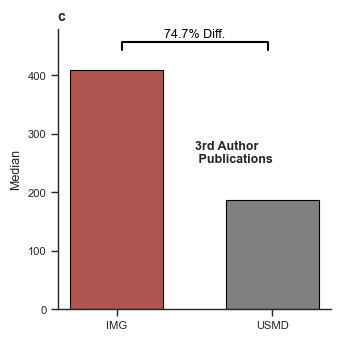

In [79]:
fig = plt.figure(figsize=(3.5,3.5))

ax = sns.barplot(df, x='IMG/USMD', y='3rdPubs', estimator=np.sum, errorbar=None, fill=True, palette=custom_palette_bar, edgecolor='black', gap=0.25, saturation=0.55)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='x', bottom=True, direction='out', labelsize=8)
ax.tick_params(axis='y', left=True, direction='out', labelsize=8)
ax.set_xlabel('')
ax.set_ylabel('Median', fontsize=9)
ax.set_title('c', fontsize=10, weight='bold', loc='left')
ax.text(x=0.5, y=250, s='3rd Author \n Publications', fontsize=9, weight='bold')
annotations = [('IMG', 'USMD', '74.7% Diff.')]
starbars.draw_annotation(annotations, text_distance=0.03, fontsize=9)


plt.tight_layout()
plt.savefig('figure4c.svg', dpi=800, bbox_inches='tight')

C:\Users\JC\AppData\Local\Temp\ipykernel_24156\3413115432.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(df, x='IMG/USMD', y='4thPubs', estimator=np.sum, errorbar=None, fill=True, palette=custom_palette_bar, edgecolor='black', gap=0.25, saturation=0.55)


2.0 0.03


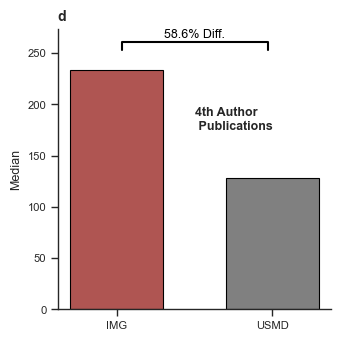

In [80]:
fig = plt.figure(figsize=(3.5,3.5))

ax = sns.barplot(df, x='IMG/USMD', y='4thPubs', estimator=np.sum, errorbar=None, fill=True, palette=custom_palette_bar, edgecolor='black', gap=0.25, saturation=0.55)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='x', bottom=True, direction='out', labelsize=8)
ax.tick_params(axis='y', left=True, direction='out', labelsize=8)
ax.set_xlabel('')
ax.set_ylabel('Median', fontsize=9)
ax.set_title('d', fontsize=10, weight='bold', loc='left')
ax.text(x=0.5, y=175, s='4th Author \n Publications', fontsize=9, weight='bold')
annotations = [('IMG', 'USMD', '58.6% Diff.')]
starbars.draw_annotation(annotations, text_distance=0.03, fontsize=9)


plt.tight_layout()
plt.savefig('figure4d.svg', dpi=800, bbox_inches='tight')

<>:10: SyntaxWarning: invalid escape sequence '\g'
<>:10: SyntaxWarning: invalid escape sequence '\g'
C:\Users\JC\AppData\Local\Temp\ipykernel_24156\4141193132.py:10: SyntaxWarning: invalid escape sequence '\g'
  ax.text(x=0.5, y=400, s='$\geq$5th Author \n Publications', fontsize=9, weight='bold')
C:\Users\JC\AppData\Local\Temp\ipykernel_24156\4141193132.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(df, x='IMG/USMD', y='5thorMorePubs', estimator=np.sum, errorbar=None, fill=True, palette=custom_palette_bar, edgecolor='black', gap=0.25, saturation=0.55)


2.0 0.03


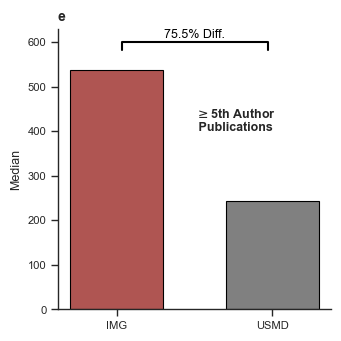

In [83]:
fig = plt.figure(figsize=(3.5,3.5))

ax = sns.barplot(df, x='IMG/USMD', y='5thorMorePubs', estimator=np.sum, errorbar=None, fill=True, palette=custom_palette_bar, edgecolor='black', gap=0.25, saturation=0.55)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='x', bottom=True, direction='out', labelsize=8)
ax.tick_params(axis='y', left=True, direction='out', labelsize=8)
ax.set_xlabel('')
ax.set_ylabel('Median', fontsize=9)
ax.set_title('e', fontsize=10, weight='bold', loc='left')
ax.text(x=0.5, y=400, s='$\geq$5th Author \n Publications', fontsize=9, weight='bold')
annotations = [('IMG', 'USMD', '75.5% Diff.')]
starbars.draw_annotation(annotations, text_distance=0.03, fontsize=9)


plt.tight_layout()
plt.savefig('figure4e.svg', dpi=800, bbox_inches='tight')

### Regression Plots

In [4]:
sns.set_context('paper')
sns.set_style('white')
mpl.rcParams['font.family'] = ['sans-serif']
mpl.rcParams['font.sans-serif'] = ['Arial']

In [5]:
df_IMG = df[df['IMG/USMD'] == 'IMG']
df_USMD = df[df['IMG/USMD'] == 'USMD']

### Histograms for Normality Testing

C:\Users\JC\AppData\Local\Temp\ipykernel_11936\3236453719.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, title='')


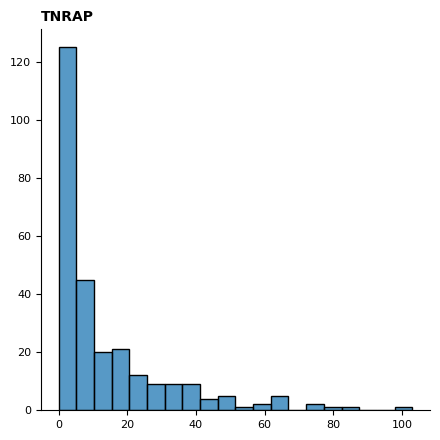

In [5]:
fig = plt.figure(figsize=(4.5,4.5))

ax = sns.histplot(df, x='TNRAP')
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='x', bottom=True, direction='out', labelsize=8)
ax.tick_params(axis='y', left=True, direction='out', labelsize=8)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('TNRAP', fontsize=10, weight='bold', loc='left')
ax.legend(frameon=False, title='')


plt.tight_layout()
plt.savefig('histogram#1', dpi=800, bbox_inches='tight')

C:\Users\JC\AppData\Local\Temp\ipykernel_11936\449750175.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, title='')


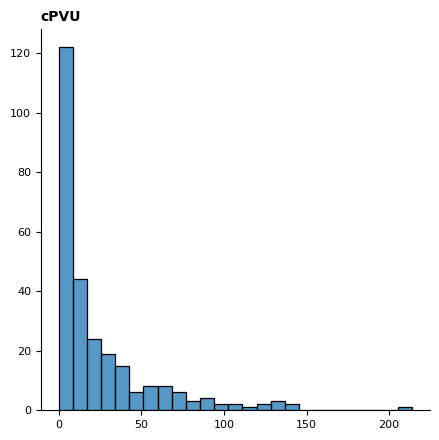

In [7]:
fig = plt.figure(figsize=(4.5,4.5))

ax = sns.histplot(df, x='cPVU')
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='x', bottom=True, direction='out', labelsize=8)
ax.tick_params(axis='y', left=True, direction='out', labelsize=8)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('cPVU', fontsize=10, weight='bold', loc='left')
ax.legend(frameon=False, title='')


plt.tight_layout()
plt.savefig('histogram#2', dpi=800, bbox_inches='tight')

C:\Users\JC\AppData\Local\Temp\ipykernel_11936\3858626293.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, title='')


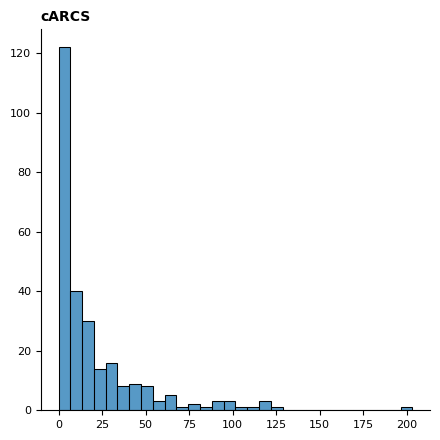

In [8]:
fig = plt.figure(figsize=(4.5,4.5))

ax = sns.histplot(df, x='cARCS')
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='x', bottom=True, direction='out', labelsize=8)
ax.tick_params(axis='y', left=True, direction='out', labelsize=8)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('cARCS', fontsize=10, weight='bold', loc='left')
ax.legend(frameon=False, title='')


plt.tight_layout()
plt.savefig('histogram#3', dpi=800, bbox_inches='tight')

C:\Users\JC\AppData\Local\Temp\ipykernel_11936\3742143224.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, title='')


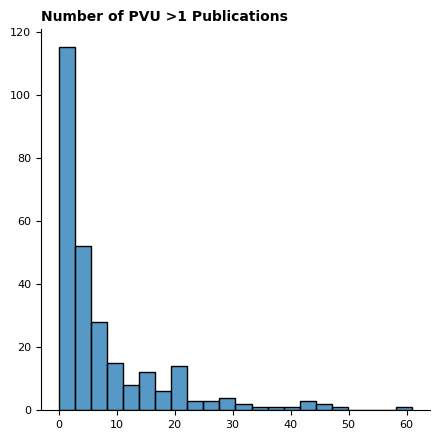

In [9]:
fig = plt.figure(figsize=(4.5,4.5))

ax = sns.histplot(df, x='PVUgt1')
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='x', bottom=True, direction='out', labelsize=8)
ax.tick_params(axis='y', left=True, direction='out', labelsize=8)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('Number of PVU >1 Publications', fontsize=10, weight='bold', loc='left')
ax.legend(frameon=False, title='')


plt.tight_layout()
plt.savefig('histogram#4', dpi=800, bbox_inches='tight')

C:\Users\JC\AppData\Local\Temp\ipykernel_7696\1131989459.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, title='')


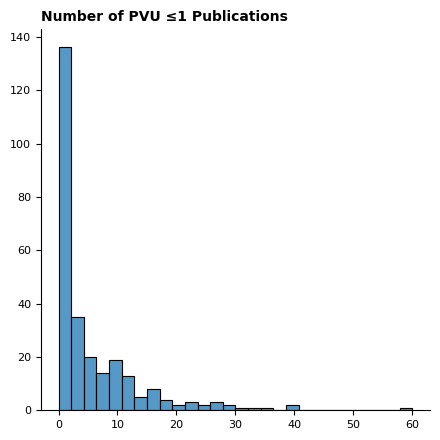

In [3]:
fig = plt.figure(figsize=(4.5,4.5))

ax = sns.histplot(df, x='PVUlt1')
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='x', bottom=True, direction='out', labelsize=8)
ax.tick_params(axis='y', left=True, direction='out', labelsize=8)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('Number of PVU ≤1 Publications', fontsize=10, weight='bold', loc='left')
ax.legend(frameon=False, title='')


plt.tight_layout()
#plt.savefig('histogram#5', dpi=800, bbox_inches='tight')

### Forestplots

In [36]:
import forestplot as fp

In [ ]:
df_irr = pd.read_excel('', sheet_name='')
df_logr = pd.read_excel('', sheet_name='')
df_linr = pd.read_excel('', sheet_name='')

<Figure size 350x350 with 0 Axes>

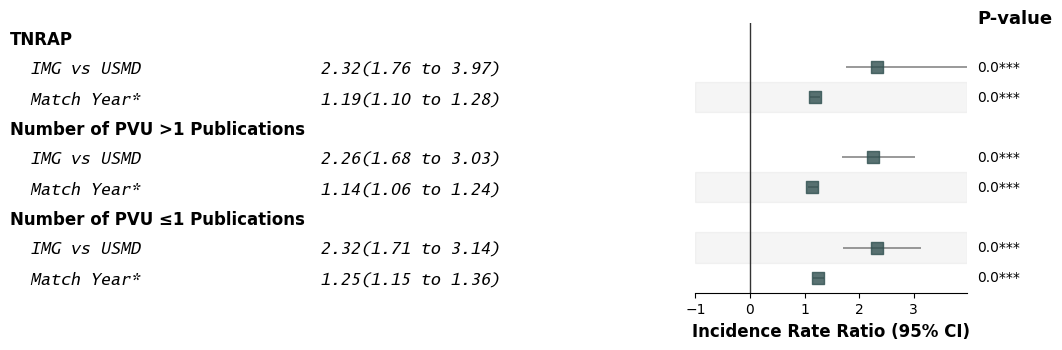

In [70]:
fig = plt.figure(figsize=(3.5,3.5))

ax = fp.forestplot(
    dataframe=df_irr,
    estimate="r",
    ll="ll",
    hl="hl",
    varlabel="variable",
    groupvar="group",           
    annote=None,          
    xlabel="Incidence Rate Ratio (95% CI)",
    ylabel="",
    pval='p',
    color_alt_rows=True,
    Table=True,

    capsize=4,
    color="red",
    marker="s",
    markersize=70,           
    ci_linewidth=2,

    ref_line=1,
    ref_line_color="red",
    ref_line_style="--",

    logscale=False,
    xticks=[-1, 0, 1, 2, 3],
    figsize=(3.5,3.5),
)

plt.tight_layout()
plt.savefig('forest1.svg', bbox_inches='tight', dpi=1200)

<Figure size 350x350 with 0 Axes>

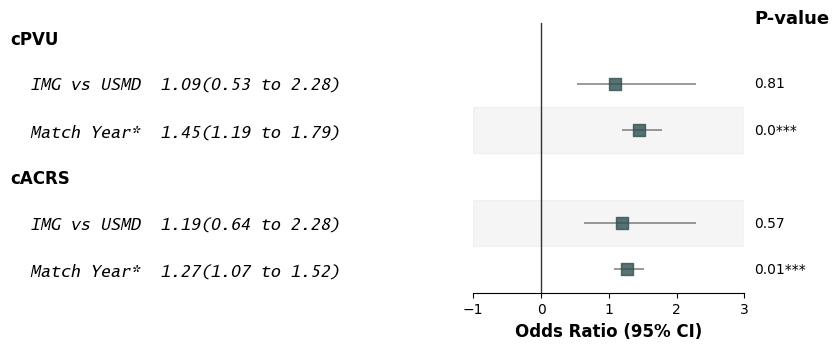

In [71]:
fig = plt.figure(figsize=(3.5,3.5))

ax = fp.forestplot(
    dataframe=df_logr,
    estimate="or",
    ll="ll",
    hl="hl",
    varlabel="variable",
    groupvar="group",           
    annote=None,          
    xlabel="Odds Ratio (95% CI)",
    ylabel="",
    pval='p',
    color_alt_rows=True,
    Table=True,

    capsize=4,
    color="red",
    marker="s",
    markersize=70,           
    ci_linewidth=2,

    ref_line=1,
    ref_line_color="red",
    ref_line_style="--",

    logscale=False,
    xticks=[-1, 0, 1, 2, 3],
    figsize=(3.5,3.5),
)

plt.tight_layout()
plt.savefig('forest2.svg', bbox_inches='tight', dpi=1200)

<Figure size 350x350 with 0 Axes>

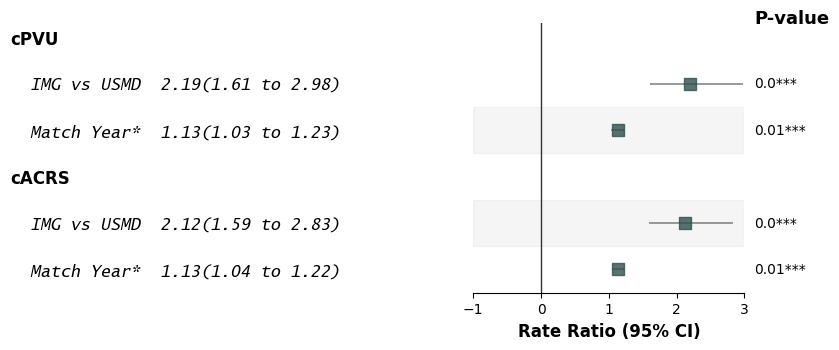

In [72]:
fig = plt.figure(figsize=(3.5,3.5))

ax = fp.forestplot(
    dataframe=df_linr,
    estimate="rr",
    ll="ll",
    hl="hl",
    varlabel="variable",
    groupvar="group",           
    annote=None,          
    xlabel="Rate Ratio (95% CI)",
    ylabel="",
    pval='p',
    color_alt_rows=True,
    Table=True,

    capsize=4,
    color="red",
    marker="s",
    markersize=70,           
    ci_linewidth=2,

    ref_line=1,
    ref_line_color="red",
    ref_line_style="--",

    logscale=False,
    xticks=[-1, 0, 1, 2, 3],
    figsize=(3.5,3.5),
)

plt.tight_layout()
plt.savefig('forest3.svg', bbox_inches='tight', dpi=1200)